In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

In [ ]:
# Load the fasion MNIST Dataset
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
#Normalize the dataset
train_images = train_images / 255.0
test_images = test_images / 255.0

In [ ]:
#Visualize Dataset
print(train_images.shape)
print(test_images.shape)
print(train_labels)

(60000, 28, 28)
(10000, 28, 28)
[9 0 0 ... 3 0 5]


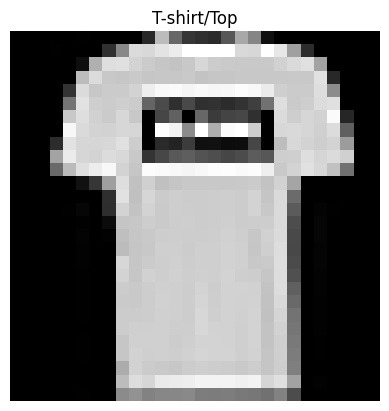

In [ ]:
# Display one fasion image
class_names = [
'T-shirt/Top',
'Trouser',
'Pullover',
'Dress',
'Coat',
'Sandal',
'Shirt',
'Sneaker',
'Bag',
'Ankle Boot'
]

# Display first image
plt.imshow(train_images[1], cmap='gray')
plt.title(class_names[train_labels[1]])
plt.axis('off')
plt.show()

In [ ]:
# Defining neural network model
my_model = tf.keras.models.Sequential()

my_model.add(tf.keras.layers.Flatten(input_shape=(28,28)))

my_model.add(tf.keras.layers.Dense(128, activation='relu'))

my_model.add(tf.keras.layers.Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Compile the model
my_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Training the model
my_model.fit(train_images, train_labels, epochs=3)

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8276 - loss: 0.4906
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8655 - loss: 0.3737
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8777 - loss: 0.3342


In [ ]:
# Test model accuracy
val_loss, val_acc = my_model.evaluate(test_images, test_labels)

print("Test Accuracy :", val_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8513 - loss: 0.3976
Test Accuracy : 0.8513000011444092


In [ ]:
# Save the model
my_model.save("fashion_mnist_model.keras")